In [1]:
import matplotlib as mpl

mpl.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
    "savefig.facecolor": "white",
    "text.color":        "black",
    "axes.labelcolor":   "black",
    "axes.edgecolor":    "#aaaaaa",
    "xtick.color":       "#aaaaaa",
    "ytick.color":       "#aaaaaa",
    "grid.color":        "#e8e8e3",
    "legend.framealpha": 0.9,
    "legend.edgecolor":  "#dddddd",
})

## Diskrete dynamiske systemer

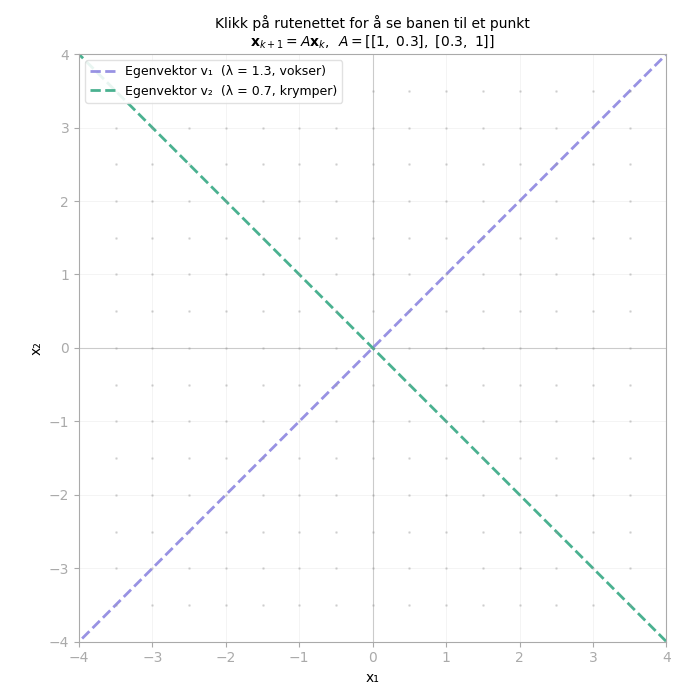

Tips: Klikk nær en egenvektorlinje og se at punktet følger den.
      Klikk langt fra begge linjene for å se dragen mot λ₁-retningen.


In [2]:
import matplotlib.pyplot as plt
plt.close('all')

%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

A = np.array([[1.0, 0.3],
              [0.3, 1.0]])

eig_vals, eig_vecs = np.linalg.eig(A)

order = np.argsort(eig_vals)[::-1]
eig_vals  = eig_vals[order]
eig_vecs  = eig_vecs[:, order]

# ─── Farger ───────────────────────────────────────────────────────────────────
COLOR_LAMBDA1 = '#7F77DD'   # Lilla: retningen som vokser (λ₁)
COLOR_LAMBDA2 = '#1D9E75'   # Grønn: retningen som krymper (λ₂)



def compute_trajectory(x0, y0, n_steps):
    pts = [np.array([x0, y0], dtype=float)]
    p = pts[0].copy()
    for _ in range(n_steps):
        p = A @ p
        pts.append(p.copy())
        if np.linalg.norm(p) > 60:
            break
    return np.array(pts)


def point_color(x0, y0):
    c1 = abs(0.5 * (x0 + y0))
    c2 = abs(0.5 * (x0 - y0))
    total = c1 + c2

    if total < 1e-10:
        return '#378ADD'

    a1 = c1 / total

    r = int(127 * a1 + 29  * (1 - a1))
    g = int(119 * a1 + 158 * (1 - a1))
    b = int(221 * a1 + 117 * (1 - a1))
    return f'#{r:02x}{g:02x}{b:02x}'


def setup_axes(ax):
    ax.clear()
    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.12, linewidth=0.5, color='gray')
    ax.axhline(0, color='gray', linewidth=0.8, alpha=0.35)
    ax.axvline(0, color='gray', linewidth=0.8, alpha=0.35)
    ax.set_xlabel('x₁', fontsize=10)
    ax.set_ylabel('x₂', fontsize=10)
    ax.set_title(
        'Klikk på rutenettet for å se banen til et punkt\n'
        r'$\mathbf{x}_{k+1} = A\mathbf{x}_k$,  $A = [[1,\ 0.3],\ [0.3,\ 1]]$',
        fontsize=10
    )

    t = np.array([-6, 6])
    v1 = eig_vecs[:, 0]  # Egenvektoren til λ₁
    v2 = eig_vecs[:, 1]  # Egenvektoren til λ₂

    slope1 = v1[1] / v1[0] if abs(v1[0]) > 1e-10 else np.inf
    slope2 = v2[1] / v2[0] if abs(v2[0]) > 1e-10 else np.inf

    ax.plot(t, slope1 * t, '--', color=COLOR_LAMBDA1, linewidth=2, alpha=0.8,
            label=f'Egenvektor v₁  (λ = {eig_vals[0]:.2g}, vokser)')
    ax.plot(t, slope2 * t, '--', color=COLOR_LAMBDA2, linewidth=2, alpha=0.8,
            label=f'Egenvektor v₂  (λ = {eig_vals[1]:.2g}, krymper)')
    ax.legend(loc='upper left', fontsize=9, framealpha=0.88)

    for x in np.arange(-3.5, 4, 0.5):
        for y in np.arange(-3.5, 4, 0.5):
            ax.plot(x, y, '.', color='#999999', markersize=2, alpha=0.28)

fig, ax = plt.subplots(figsize=(7, 7))
setup_axes(ax)
plotted_trajectories = []   # Holder styr på alle baner som er tegnet


def on_click(event):
    if event.inaxes != ax or event.button != 1:
        return

    x0, y0 = event.xdata, event.ydata
    if x0 is None or y0 is None:
        return

    n = step_slider.value
    traj = compute_trajectory(x0, y0, n)
    color = point_color(x0, y0)

    for i in range(len(traj) - 1):
        alpha = max(0.12, 0.9 - i * (0.78 / n))
        ax.plot(traj[i:i+2, 0], traj[i:i+2, 1],
                '-', color=color, linewidth=1.4, alpha=alpha, zorder=3)

    for i, pt in enumerate(traj):
        alpha = max(0.12, 1.0 - i * (0.85 / (n + 1)))
        size  = max(3.0, 9.5 - i * (6.0 / (n + 1)))
        ax.plot(pt[0], pt[1], 'o',
                color=color, markersize=size, alpha=alpha,
                markeredgecolor='white', markeredgewidth=0.5, zorder=5)

    ax.plot(x0, y0, '*',
            color=color, markersize=14,
            markeredgecolor='white', markeredgewidth=0.8, zorder=10)

    if len(traj) > 1:
        delta = traj[1] - traj[0]
        if np.linalg.norm(delta) > 0.04:   # Unngå piler for svært korte steg
            ax.annotate(
                '',
                xy=traj[1], xytext=traj[0],
                arrowprops=dict(arrowstyle='->', color=color, lw=1.6),
                zorder=8
            )

    plotted_trajectories.append(traj)
    fig.canvas.draw_idle()


def on_clear(_):
    setup_axes(ax)
    plotted_trajectories.clear()
    fig.canvas.draw_idle()


fig.canvas.mpl_connect('button_press_event', on_click)

step_slider = widgets.IntSlider(
    value=10, min=3, max=30, step=1,
    description='Antall steg:',
    layout=widgets.Layout(width='360px'),
    style={'description_width': '115px'}
)
clear_btn = widgets.Button(
    description='Nullstill',
    button_style='',
    layout=widgets.Layout(width='100px')
)
clear_btn.on_click(on_clear)

display(widgets.HBox([step_slider, clear_btn]))
plt.tight_layout()
plt.show()

print("Tips: Klikk nær en egenvektorlinje og se at punktet følger den.")
print("      Klikk langt fra begge linjene for å se dragen mot λ₁-retningen.")

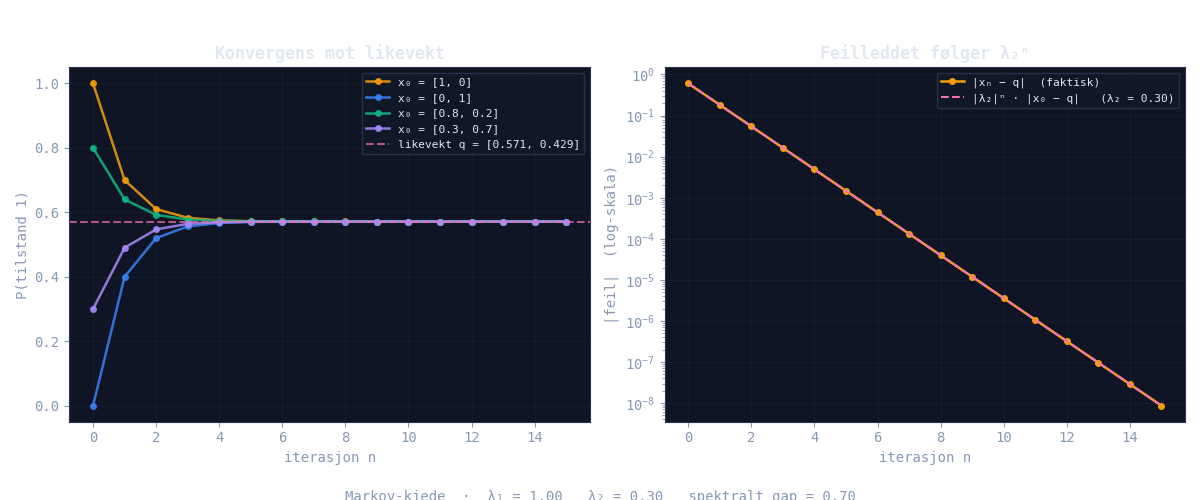

In [3]:
import matplotlib.pyplot as plt
plt.close('all')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# --- Overgangsmatrise (kolonne-stokastisk) ---
P = np.array([
    [0.7, 0.4],
    [0.3, 0.6]
])

# --- Egenverdier og likevektsvektor ---
eigenvalues, eigenvectors = np.linalg.eig(P)

# Finn egenvektoren med λ = 1 og normaliser til sannsynlighetsvektor
idx = np.argmin(np.abs(eigenvalues - 1))
steady = np.real(eigenvectors[:, idx])
steady = steady / steady.sum()

lambda2 = eigenvalues[1 - idx]

# --- Iterasjon fra ulike startvektorer ---
starts = [
    np.array([1.0, 0.0]),
    np.array([0.0, 1.0]),
    np.array([0.8, 0.2]),
    np.array([0.3, 0.7]),
]
labels = ["[1, 0]", "[0, 1]", "[0.8, 0.2]", "[0.3, 0.7]"]
colors = ["#f59e0b", "#3b82f6", "#10b981", "#a78bfa"]

n_steps = 15

def iterate(P, x0, n):
    trajectory = [x0.copy()]
    x = x0.copy()
    for _ in range(n):
        x = P @ x
        trajectory.append(x.copy())
    return np.array(trajectory)

trajectories = [iterate(P, s, n_steps) for s in starts]

# --- Plotting ---
mpl.rcParams.update({
    "font.family": "monospace",
    "font.size": 10,
    "axes.facecolor": "#0f1524",
    "figure.facecolor": "#0a0f1a",
    "text.color": "#e2e8f0",
    "axes.edgecolor": "#2a3550",
    "axes.labelcolor": "#8899b4",
    "xtick.color": "#8899b4",
    "ytick.color": "#8899b4",
    "grid.color": "#1e293b",
    "grid.alpha": 0.6,
})

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Plot 1: Konvergens mot likevekt ---
ax = axes[0]
ns = np.arange(n_steps + 1)

for traj, label, color in zip(trajectories, labels, colors):
    ax.plot(ns, traj[:, 0], "o-", color=color, label=f"x₀ = {label}",
            markersize=4, linewidth=1.8, alpha=0.85)

ax.axhline(y=steady[0], color="#f472b6", linestyle="--", linewidth=1.5,
           alpha=0.7, label=f"likevekt q = [{steady[0]:.3f}, {steady[1]:.3f}]")

ax.set_xlabel("iterasjon n")
ax.set_ylabel("P(tilstand 1)")
ax.set_title("Konvergens mot likevekt", color="#e2e8f0", fontsize=12, fontweight="bold")
ax.legend(fontsize=8, facecolor="#111827", edgecolor="#2a3550", labelcolor="#e2e8f0")
ax.grid(True, linewidth=0.5)
ax.set_ylim(-0.05, 1.05)

# --- Plot 2: Feilleddet vs λ₂ⁿ ---
ax2 = axes[1]

traj = trajectories[0]  # bruker x₀ = [1, 0]
errors = np.linalg.norm(traj - steady, axis=1)
theoretical = errors[0] * np.abs(lambda2) ** ns

ax2.semilogy(ns, errors, "o-", color="#f59e0b", markersize=4,
             linewidth=1.8, label="|xₙ − q|  (faktisk)")
ax2.semilogy(ns, theoretical, "--", color="#f472b6",
             linewidth=1.5, label=f"|λ₂|ⁿ · |x₀ − q|   (λ₂ = {np.real(lambda2):.2f})")

ax2.set_xlabel("iterasjon n")
ax2.set_ylabel("|feil|  (log-skala)")
ax2.set_title("Feilleddet følger λ₂ⁿ", color="#e2e8f0", fontsize=12, fontweight="bold")
ax2.legend(fontsize=8, facecolor="#111827", edgecolor="#2a3550", labelcolor="#e2e8f0")
ax2.grid(True, linewidth=0.5)

# --- Info-tekst ---
fig.suptitle(
    f"Markov-kjede  ·  λ₁ = {np.real(eigenvalues[idx]):.2f}   λ₂ = {np.real(lambda2):.2f}   spektralt gap = {1 - abs(lambda2):.2f}",
    color="#8899b4", fontsize=10, y=0.02
)

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

## Gram-Schmidt ortogonalisering

interactive(children=(FloatSlider(value=2.0, description='v₁ x', max=3.0, min=-3.0), FloatSlider(value=1.0, de…

<function __main__.plot_gram_schmidt(v1x=2.0, v1y=1.0, v2x=1.0, v2y=2.5, step=4)>

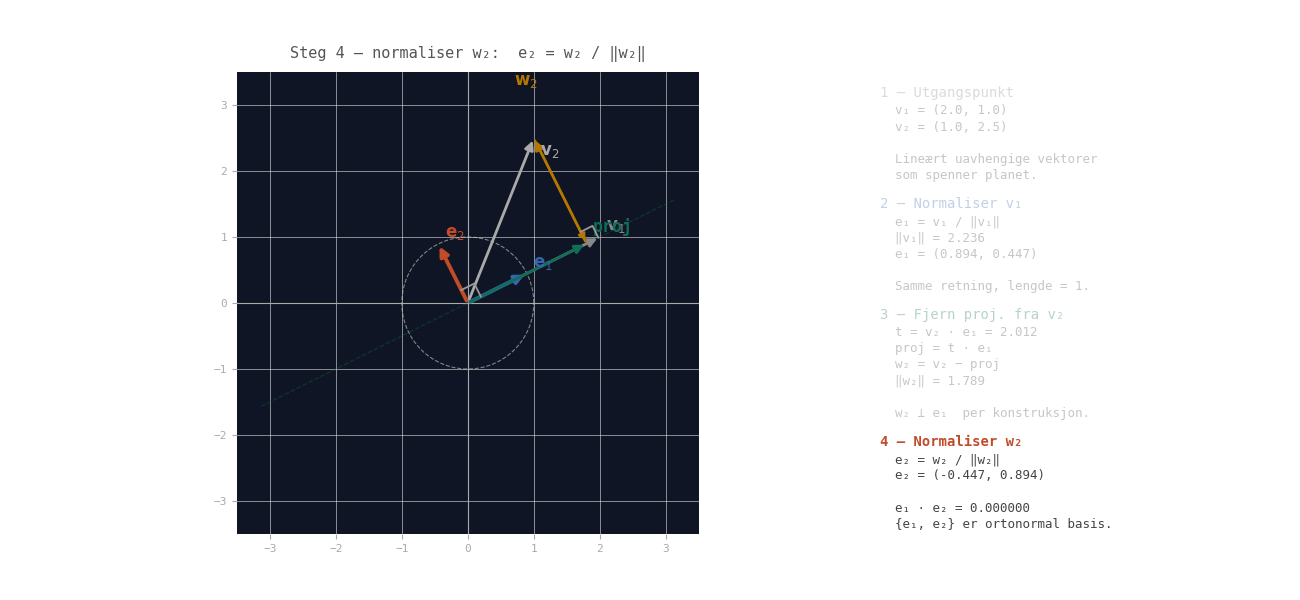

In [4]:
import matplotlib.pyplot as plt
plt.close('all')

from ipywidgets import interact, FloatSlider, IntSlider
import warnings
warnings.filterwarnings("ignore")


def draw_arrow(ax, origin, tip, color, lw=2.2, alpha=1.0,
               linestyle="-", label=None, label_offset=(0.1, 0.1)):
    ax.annotate(
        "", xy=tip, xytext=origin,
        arrowprops=dict(arrowstyle="-|>", color=color, lw=lw,
                        mutation_scale=13, linestyle=linestyle),
        alpha=alpha, zorder=5,
    )
    if label:
        ax.text(tip[0] + label_offset[0], tip[1] + label_offset[1],
                label, color=color, fontsize=12,
                fontweight="bold", zorder=6)


def draw_right_angle(ax, corner, dir1, dir2, size=0.15, color="#888888"):
    d1 = np.array(dir1) - np.array(corner)
    d2 = np.array(dir2) - np.array(corner)
    n1, n2 = np.linalg.norm(d1), np.linalg.norm(d2)
    if n1 < 1e-9 or n2 < 1e-9:
        return
    u1, u2 = d1 / n1, d2 / n2
    c1 = np.array(corner) + u1 * size
    c2 = c1 + u2 * size
    c3 = np.array(corner) + u2 * size
    xs = [c1[0], c2[0], c3[0]]
    ys = [c1[1], c2[1], c3[1]]
    ax.plot(xs, ys, color=color, linewidth=1.3, zorder=6)


def setup_ax(ax, lim=3.5):
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect("equal")
    ax.axhline(0, color="#aaaaaa", linewidth=0.8, zorder=1)
    ax.axvline(0, color="#aaaaaa", linewidth=0.8, zorder=1)
    for i in np.arange(np.ceil(-lim), np.floor(lim) + 1):
        ax.axhline(i, color="#e8e8e3", linewidth=0.4, zorder=0)
        ax.axvline(i, color="#e8e8e3", linewidth=0.4, zorder=0)
    ax.set_xticks(range(int(np.ceil(-lim)), int(np.floor(lim)) + 1))
    ax.set_yticks(range(int(np.ceil(-lim)), int(np.floor(lim)) + 1))
    ax.tick_params(labelsize=8, colors="#aaaaaa")
    for spine in ax.spines.values():
        spine.set_visible(False)

V1_COL   = "#888888"   # v1 (grå)
V2_COL   = "#aaaaaa"   # v2 (lysere grå)
E1_COL   = "#3266ad"   # e1 (blå)
E2_COL   = "#c24b2a"   # e2 (rød)
PROJ_COL = "#0f6e56"   # projeksjon (grønn)
W2_COL   = "#b47800"   # w2 (gul)

def plot_gram_schmidt(v1x=2.0, v1y=1.0, v2x=1.0, v2y=2.5, step=4):
    v1 = np.array([v1x, v1y])
    v2 = np.array([v2x, v2y])

    n1 = np.linalg.norm(v1)
    if n1 < 0.1:
        print("v₁ kan ikke være nullvektoren.")
        return

    e1   = v1 / n1
    t    = np.dot(v2, e1)
    proj = t * e1
    w2v  = v2 - proj
    n2   = np.linalg.norm(w2v)
    degenerate = n2 < 0.08

    fig, axes = plt.subplots(1, 2, figsize=(13, 6),
                             gridspec_kw={"width_ratios": [2, 1]})
    ax     = axes[0]
    ax_txt = axes[1]

    setup_ax(ax, lim=3.5)

    step_titles = [
        "Steg 1 — utgangspunkt: v₁ og v₂",
        "Steg 2 — normaliser v₁:  e₁ = v₁ / ‖v₁‖",
        "Steg 3 — trekk fra projeksjon:  w₂ = v₂ − (v₂·e₁)e₁",
        "Steg 4 — normaliser w₂:  e₂ = w₂ / ‖w₂‖",
    ]
    ax.set_title(step_titles[step - 1], fontsize=11, pad=10,
                 color="#555555", fontweight="normal")

    # --- Steg 1: vis v1 og v2 ---
    alpha_v = 1.0 if step >= 1 else 0.15
    draw_arrow(ax, [0, 0], v1, V1_COL, lw=2.0, alpha=alpha_v,
               label=r"$\mathbf{v}_1$", label_offset=[0.1, 0.1])
    draw_arrow(ax, [0, 0], v2, V2_COL, lw=2.0, alpha=alpha_v,
               label=r"$\mathbf{v}_2$", label_offset=[0.1, -0.25])

    if step >= 2:
        theta = np.linspace(0, 2 * np.pi, 300)
        ax.plot(np.cos(theta), np.sin(theta),
                color="#cccccc", linewidth=0.8,
                linestyle="--", alpha=0.6, zorder=2)
        draw_arrow(ax, [0, 0], e1, E1_COL, lw=2.8,
                   label=r"$\mathbf{e}_1$", label_offset=[0.1, 0.1])

    if step >= 3:
        ext = 3.5
        ax.plot([-e1[0]*ext, e1[0]*ext], [-e1[1]*ext, e1[1]*ext],
                color=PROJ_COL, linewidth=0.9,
                linestyle="--", alpha=0.35, zorder=2)

        draw_arrow(ax, [0, 0], proj, PROJ_COL, lw=2.0,
                   label="proj", label_offset=[0.1, 0.18])

        if not degenerate:
            ax.annotate(
                "", xy=proj, xytext=v2,
                arrowprops=dict(arrowstyle="-|>", color=W2_COL,
                                lw=1.5, mutation_scale=11,
                                linestyle="dashed"),
                alpha=0.7, zorder=4,
            )
            draw_arrow(ax, proj, v2, W2_COL, lw=2.0,
                       label=r"$\mathbf{w}_2$",
                       label_offset=[(v2[0]-proj[0])*.5 + 0.1,
                                     (v2[1]-proj[1])*.5])
            draw_right_angle(ax, proj, v2, proj + e1,
                             size=0.2, color="#999999")

    if step >= 4 and not degenerate:
        e2 = w2v / n2
        draw_arrow(ax, [0, 0], e2, E2_COL, lw=2.8,
                   label=r"$\mathbf{e}_2$", label_offset=[0.1, 0.1])
        draw_right_angle(ax, [0, 0], e1, e2,
                        size=0.22, color="#999999")

    ax_txt.axis("off")
    ax_txt.set_xlim(0, 1)
    ax_txt.set_ylim(0, 1)

    panel_steps = [
        {
            "title": "1 — Utgangspunkt",
            "color": V1_COL,
            "lines": [
                f"v₁ = ({v1x:.1f}, {v1y:.1f})",
                f"v₂ = ({v2x:.1f}, {v2y:.1f})",
                "",
                "Lineært uavhengige vektorer",
                "som spenner planet.",
            ],
        },
        {
            "title": "2 — Normaliser v₁",
            "color": E1_COL,
            "lines": [
                r"e₁ = v₁ / ‖v₁‖",
                f"‖v₁‖ = {n1:.3f}",
                f"e₁ = ({e1[0]:.3f}, {e1[1]:.3f})",
                "",
                "Samme retning, lengde = 1.",
            ],
        },
        {
            "title": "3 — Fjern proj. fra v₂",
            "color": PROJ_COL,
            "lines": [
                "t = v₂ · e₁" + f" = {t:.3f}",
                "proj = t · e₁",
                "w₂ = v₂ − proj",
                f"‖w₂‖ = {n2:.3f}",
                "",
                "w₂ ⊥ e₁  per konstruksjon.",
            ],
        },
        {
            "title": "4 — Normaliser w₂",
            "color": E2_COL,
            "lines": [
                r"e₂ = w₂ / ‖w₂‖",
                *(([f"e₂ = ({w2v[0]/n2:.3f}, {w2v[1]/n2:.3f})"] if not degenerate
                  else ["(v₁ ∥ v₂ — degenert tilfelle)"])),
                "",
                "e₁ · e₂ = "
                + (f"{np.dot(e1, w2v/n2):.6f}" if not degenerate else "—"),
                "{e₁, e₂} er ortonormal basis.",
            ],
        },
    ]

    y = 0.97
    for i, ps in enumerate(panel_steps):
        active = (i + 1 == step)
        alpha  = 1.0 if active else 0.3
        ax_txt.text(0.05, y, ps["title"],
                    transform=ax_txt.transAxes,
                    fontsize=10, fontweight="bold" if active else "normal",
                    color=ps["color"], alpha=alpha, va="top")
        y -= 0.04
        for line in ps["lines"]:
            ax_txt.text(0.1, y, line,
                        transform=ax_txt.transAxes,
                        fontsize=9, color="#444444",
                        fontfamily="monospace", alpha=alpha, va="top")
            y -= 0.035
        y -= 0.025

    legend_elements = [
        mpatches.Patch(color=V1_COL,   label=r"$\mathbf{v}_1$, $\mathbf{v}_2$ — original"),
        mpatches.Patch(color=E1_COL,   label=r"$\mathbf{e}_1$ — 1. ortonormale vektor"),
        mpatches.Patch(color=PROJ_COL, label="proj — projeksjon av v₂ på e₁"),
        mpatches.Patch(color=W2_COL,   label=r"$\mathbf{w}_2$ — ortogonal komponent"),
        mpatches.Patch(color=E2_COL,   label=r"$\mathbf{e}_2$ — 2. ortonormale vektor"),
    ]
    ax.legend(handles=legend_elements, loc="lower right",
              fontsize=8.5, framealpha=0.9, edgecolor="#dddddd")

    plt.tight_layout(pad=2.0)
    plt.show()


slider_kw = dict(min=-3.0, max=3.0, step=0.1, continuous_update=True)
interact(
    plot_gram_schmidt,
    v1x=FloatSlider(value=2.0,  description="v₁ x", **slider_kw),
    v1y=FloatSlider(value=1.0,  description="v₁ y", **slider_kw),
    v2x=FloatSlider(value=1.0,  description="v₂ x", **slider_kw),
    v2y=FloatSlider(value=2.5,  description="v₂ y", **slider_kw),
    step=IntSlider(value=4, min=1, max=4, step=1,
                   description="steg",
                   style={"description_width": "40px"}),
)